In [5]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Ensure output folders exist
os.makedirs('results/benign', exist_ok=True)
os.makedirs('results/malignant', exist_ok=True)

print("Libraries loaded. TensorFlow version:", tf.__version__)

Libraries loaded. TensorFlow version: 2.20.0


In [6]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    'dataset/',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Validation split from the same dataset
val_data = datagen.flow_from_directory(
    'dataset/',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# 2. Define CNN Architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train with validation
print("Training started...")
history = model.fit(train_data, validation_data=val_data, epochs=10)  # Adjust epochs if you want higher accuracy
model.save('model.h5')
print("Model trained and saved as model.h5")

Found 2400 images belonging to 2 classes.
Found 600 images belonging to 2 classes.
Training started...
Epoch 1/10


c:\Users\wwwsh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 297ms/step - accuracy: 0.7683 - loss: 0.6223 - val_accuracy: 0.8683 - val_loss: 0.3346
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 285ms/step - accuracy: 0.8858 - loss: 0.2765 - val_accuracy: 0.9450 - val_loss: 0.1635
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 279ms/step - accuracy: 0.9450 - loss: 0.1631 - val_accuracy: 0.9617 - val_loss: 0.1012
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 286ms/step - accuracy: 0.9625 - loss: 0.1020 - val_accuracy: 0.9867 - val_loss: 0.0606
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 283ms/step - accuracy: 0.9821 - loss: 0.0651 - val_accuracy: 0.9933 - val_loss: 0.0313
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 286ms/step - accuracy: 0.9883 - loss: 0.0439 - val_accuracy: 1.0000 - val_loss: 0.0231
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 283ms/step - accuracy: 0.9917 - loss: 0.0298 - val_accuracy: 0.9983 - val_loss: 0.0164
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 281ms/step - accuracy: 0.9950 - loss: 0.0224 - val_accuracy: 0.988

Model trained and saved as model.h5


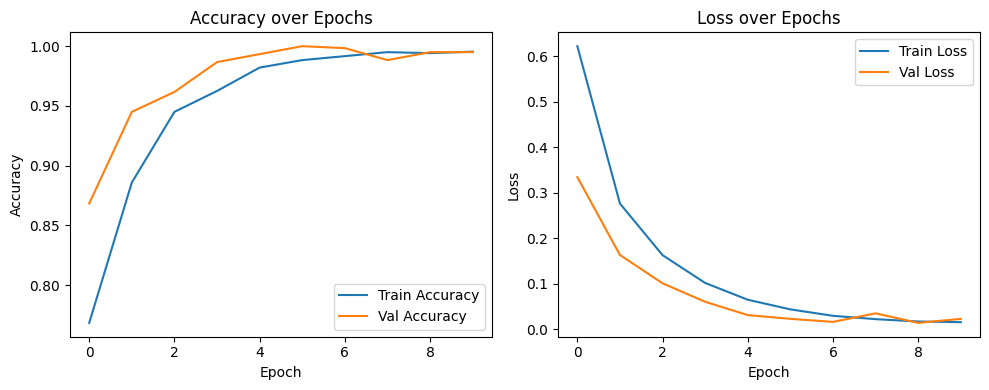

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# ── Plot Training & Validation Loss ──
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Found 600 images belonging to 2 classes.
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step


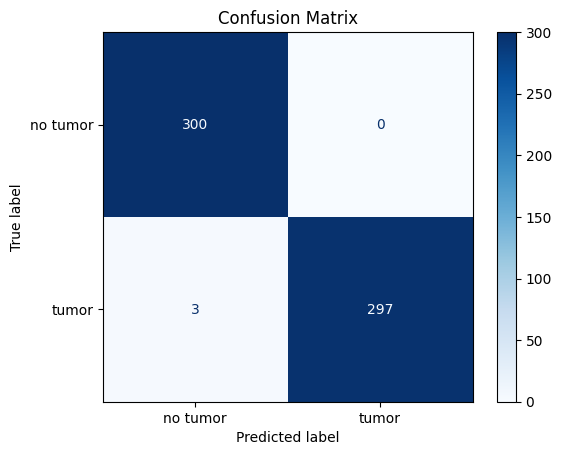

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# IMPORTANT: validation generator (must be defined before this)
val_data = datagen.flow_from_directory(
    'dataset/',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# True labels
y_true = val_data.classes

# Predictions
y_pred_prob = model.predict(val_data)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no tumor', 'tumor'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [16]:
from sklearn.metrics import precision_score, recall_score

# True labels
y_true = val_data.classes

# Predictions
y_pred_prob = model.predict(val_data)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Precision
precision = precision_score(y_true, y_pred)

# Recall
recall = recall_score(y_true, y_pred)

print("Precision:", precision)
print("Recall:", recall)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
Precision: 1.0
Recall: 0.99


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step


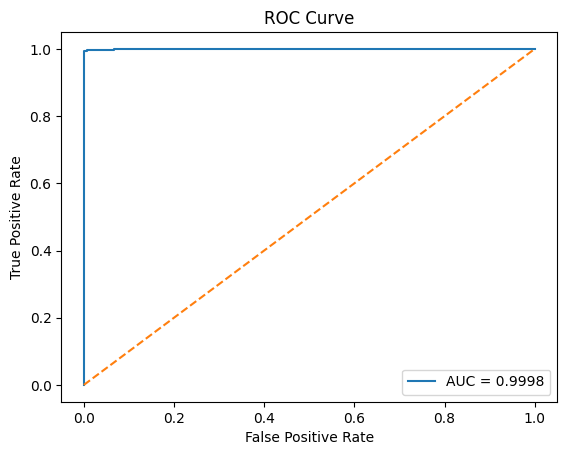

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# True labels
y_true = val_data.classes

# Predicted probabilities (NOT binary)
y_pred_prob = model.predict(val_data)

# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [11]:
def process_scans():
    model = tf.keras.models.load_model('model.h5')
    patient_path = 'patient/'
    files = [f for f in os.listdir(patient_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not files:
        print("No new images found in the 'patient' folder.")
        return

    for filename in files:
        img_path = os.path.join(patient_path, filename)
        
        # Prepare image
        img = load_img(img_path, target_size=(150, 150))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_array)
        
        # Determine Folder & Label
        if prediction[0] > 0.5:
            label = "Malignant"
            dest = os.path.join('results/malignant', filename)
        else:
            label = "Benign"
            dest = os.path.join('results/benign', filename)

        # Move the file
        shutil.move(img_path, dest)
        print(f"Processed {filename}: Classified as {label}")

process_scans()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Processed pred0.jpg: Classified as Benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Processed pred1.jpg: Classified as Benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Processed pred10.jpg: Classified as Malignant
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Processed pred11.jpg: Classified as Malignant
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Processed pred12.jpg: Classified as Benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Processed pred13.jpg: Classified as Malignant
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Processed pred14.jpg: Classified as Malignant
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Processed pred15.jpg: Classified as Benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Processed pred16.jpg: Classified as Malignant
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Processed pred17.jpg: Classified as Benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Processed pred18.jpg: Classified as Benign
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Processed pred19.jpg: Classified as Benign
1/1 ━━━━━━━━━━━

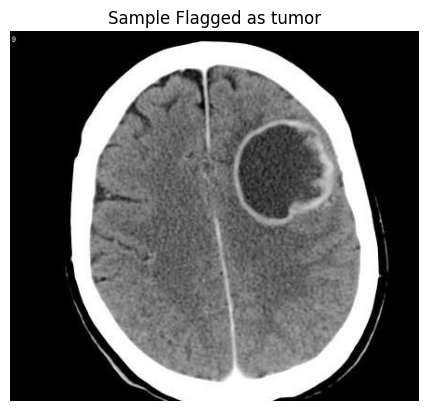

In [12]:
mal_folder = 'results/malignant/'
mal_files = os.listdir(mal_folder)

if mal_files:
    sample_img = load_img(os.path.join(mal_folder, mal_files[0]))
    plt.imshow(sample_img)
    plt.title("Sample Flagged as tumor")
    plt.axis('off')
    plt.show()
else:
    print("No malinant scans to display.")

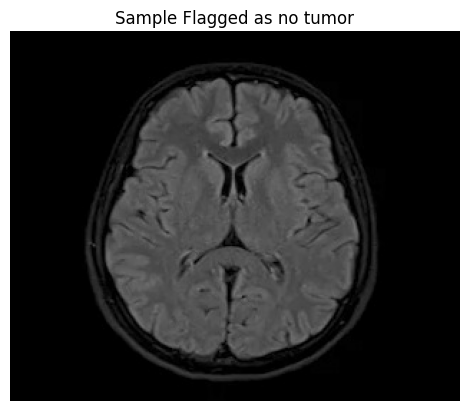

In [13]:
# Show the first image in the malignant folder to verify
mal_folder = 'results/benign/'
mal_files = os.listdir(mal_folder)

if mal_files:
    sample_img = load_img(os.path.join(mal_folder, mal_files[0]))
    plt.imshow(sample_img)
    plt.title("Sample Flagged as no tumor")
    plt.axis('off')
    plt.show()
else:
    print("No  scans to display.")